#  Study on Binary AlphaDigit

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from principal_RBM_alpha import RBM
from principal_DBN_alpha import DBN

## Hyperparameters + Utils

In [2]:
PATH_MAT = "data/binaryalphadigs.mat"
SEED = 42
np.random.seed(SEED)

# Hyperparameters
EPOCHS = 100
LEARNING_RATE = 0.1
BATCH_SIZE = 10
ITER_GIBBS = 1000
NB_IMAGES_GEN = 10

# utils
def plot_comparison(images_list: list, titles: list, super_title: str) -> None:
    """Plot a grid of images for comparison."""
    fig, axes = plt.subplots(len(images_list), NB_IMAGES_GEN, figsize=(NB_IMAGES_GEN * 1.5, len(images_list) * 2))
    fig.suptitle(super_title, fontsize=16)
    
    for row, (images, title) in enumerate(zip(images_list, titles)):
        axes[row, 0].set_ylabel(title, size='large', rotation=0, labelpad=40, ha='right')
        for col in range(NB_IMAGES_GEN):
            ax = axes[row, col]
            ax.imshow(images[col].reshape(20, 16), cmap='gray')
            ax.set_xticks([])
            ax.set_yticks([])
    plt.tight_layout()
    plt.show()

## RMB & DBN Training + Image Generation

In [3]:
chars_rbm = ["A", "B", "C"]
data_rbm = RBM.lire_alpha_digit(PATH_MAT, chars_rbm)

# network architecture parameters
input_size = 320
network_size = [input_size, 200, 100]

**RBM**

Training RBM: 100%|██████████| 100/100 [00:01<00:00, 72.82epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.0042]


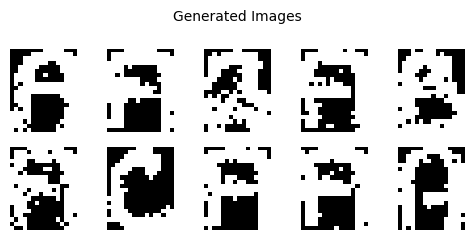

In [4]:
# rbm initialization (single hidden layer)
p = input_size
q = network_size[1]
rbm_model = RBM(p, q)

rbm_model.train_RBM(data_rbm, epochs=EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE, verbose=True)
rmb_gen_images = rbm_model.generer_image_RBM(nb_images=NB_IMAGES_GEN, iter_gibbs=ITER_GIBBS)

**DBN**


--- Pre-training DBN Layer 1/2 ---


Training RBM: 100%|██████████| 100/100 [00:01<00:00, 80.00epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.0041]



--- Pre-training DBN Layer 2/2 ---


Training RBM: 100%|██████████| 100/100 [00:00<00:00, 203.39epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.0091]


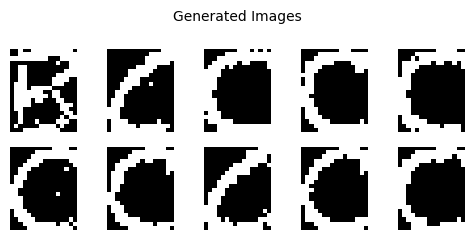

In [5]:
chars = ["A", "B", "C"]
data_dbn = RBM.lire_alpha_digit(PATH_MAT, chars)
# dbn instantiation and layer-wise training
dbn_model = DBN(network_size)
dbn_model.train_DBN(data_dbn, epochs=EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE, verbose=True)
dbn_generated_images = dbn_model.generer_image_DBN(nb_images=NB_IMAGES_GEN, iter_gibbs=ITER_GIBBS)

For the numbers part (0 to 3), DBN outperforms completely RBM, because it has more parameters and can learn better the distribution of the data, while RBM is more likely to get stuck in a local minimum.

### Impact of hidden layer size on RBM performance

Training RBM with q=10...


Training RBM:  65%|██████▌   | 65/100 [00:00<00:00, 327.55epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.1279]c:\Users\thoma\OneDrive\Documents\ECE\ING5\P3\DLII\Project\principal_RBM_alpha.py:67: RuntimeWarning: overflow encountered in exp
  res = 1 / (1 + np.exp(-x))
Training RBM: 100%|██████████| 100/100 [00:00<00:00, 337.90epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.1265]


Training RBM with q=100...


Training RBM: 100%|██████████| 100/100 [00:00<00:00, 209.68epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.0155]


Training RBM with q=500...


Training RBM: 100%|██████████| 100/100 [00:01<00:00, 69.81epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.0005]


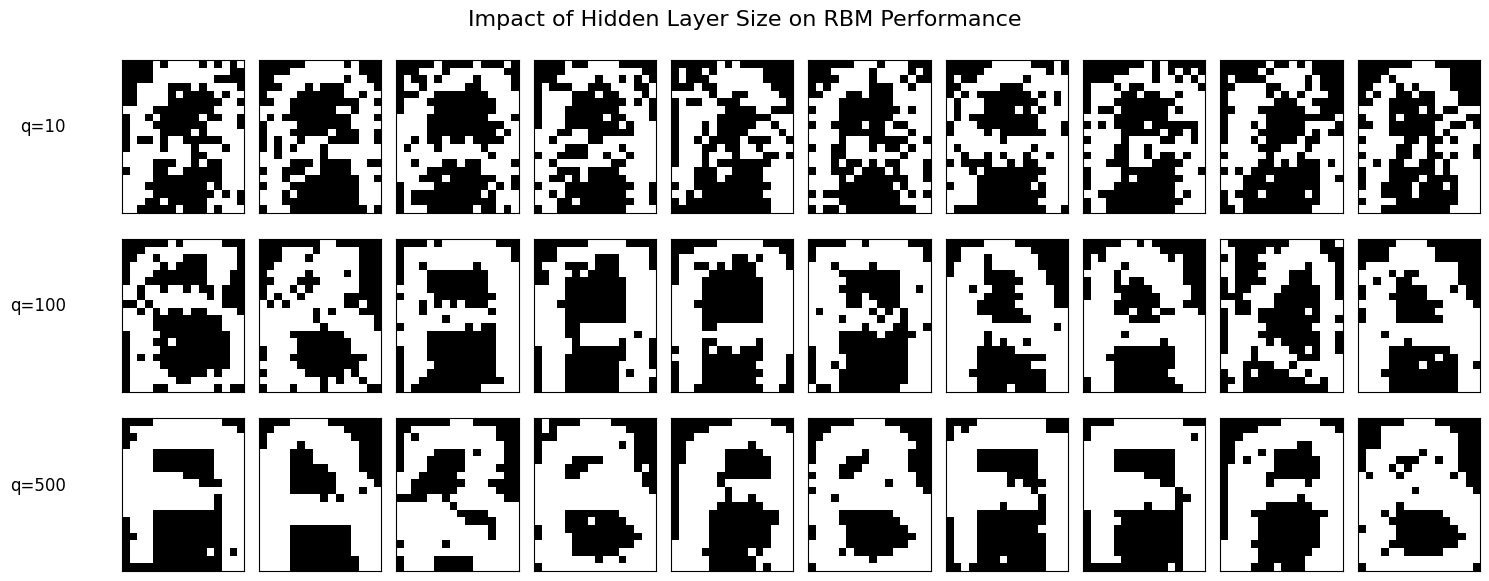

In [6]:
chars = ['A', 'B']
data = RBM.lire_alpha_digit(PATH_MAT, chars)
p = np.size(data, 1)

sizes_q = [10, 100, 500] # Test: small, medium, large, very large hidden layer sizes
results = []
titles = []

for q in sizes_q:
    print(f"Training RBM with q={q}...")
    rbm = RBM(p, q)
    rbm.train_RBM(data, EPOCHS, LEARNING_RATE, BATCH_SIZE, verbose=True) # Training unsupervised
    images = rbm.generer_image_RBM(NB_IMAGES_GEN, ITER_GIBBS, display=False)
    results.append(images)
    titles.append(f"q={q}")

plot_comparison(results, titles, "Impact of Hidden Layer Size on RBM Performance")

> The results demonstrate the direct relationship between parameter capacity and generative fidelity.

**Observation:**
At a restricted capacity ($q=10$), the network acts as an informational bottleneck. It lacks the parameters to fully map the pixel correlations, resulting in noisy, ambiguous shapes.

**Conclusion:** As the number of hidden units increases ($q=100$ to $500$), the RBM gains sufficient memory to separate the distinct probability distributions of the letters 'A' and 'B', resulting in sharp, highly recognizable generations without any noise in the samples. This illustrates how a larger hidden layer allows the model to capture more complex data distributions, leading to higher quality generations.

### Impact of Network Depth (DBN vs RBM)

Training DBN with architecture [320, 100]...

--- Pre-training DBN Layer 1/1 ---


Training RBM: 100%|██████████| 100/100 [00:00<00:00, 102.36epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.0198]


Training DBN with architecture [320, 100, 100]...

--- Pre-training DBN Layer 1/2 ---


Training RBM: 100%|██████████| 100/100 [00:00<00:00, 113.90epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.0197]



--- Pre-training DBN Layer 2/2 ---


...

Training RBM: 100%|██████████| 100/100 [00:00<00:00, 108.04epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.0205]



--- Pre-training DBN Layer 2/3 ---


Training RBM: 100%|██████████| 100/100 [00:00<00:00, 185.46epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.0113]



--- Pre-training DBN Layer 3/3 ---


Training RBM: 100%|██████████| 100/100 [00:00<00:00, 194.70epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.0084]


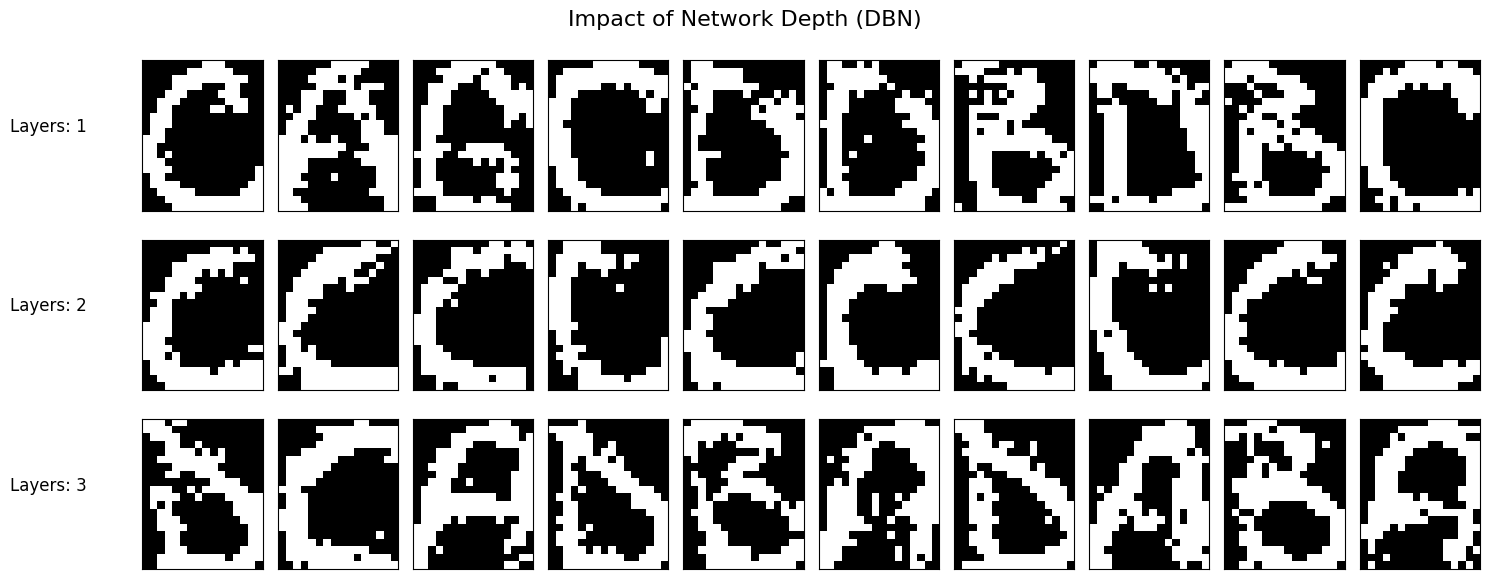

In [7]:
chars = ["A", "B", "C", "D"]
data = RBM.lire_alpha_digit(PATH_MAT, chars)
p = np.size(data, 1)

architectures = [
    [p, 100],                 # 1-layer (RBM)
    [p, 100, 100],            # 2-layer DBN
    [p, 100, 100, 100]        # 3-layer DBN
]

results = []
titles = []

for arch in architectures:
    print(f"Training DBN with architecture {arch}...")
    dbn = DBN(arch)
    dbn.train_DBN(data, EPOCHS, LEARNING_RATE, BATCH_SIZE, verbose=True) # Unsupervised DBN pre-training
    images = dbn.generer_image_DBN(NB_IMAGES_GEN, ITER_GIBBS, display=False)
    results.append(images)
    titles.append(f"Layers: {len(arch)-1}")
    
plot_comparison(results, titles, "Impact of Network Depth (DBN)")

> This visually confirms the advantage of hierarchical learning in Deep Belief Networks.

**Observation:** The 1-layer network (a standard RBM) produces binary images that, while recognizable, contain high-frequency background noise. Conversely, the 2-layer and 3-layer DBNs generate significantly smoother and structurally coherent characters. 3-layer is even better than 2-layer because it seems to be a lot more diverse in the generated characters, while 2-layer seems to be more "stuck", this is due to the fact that 2-layer is more likely to get stuck in a local minimum, while 3-layer has more parameters and can escape it.

**Conclusion:** By stacking layers, the DBN learns hierarchical representations, lower layers capture local strokes, while higher layers govern global shapes.

### Impact of Number of Characters

Training on 1 characters...

--- Pre-training DBN Layer 1/2 ---


Training RBM: 100%|██████████| 100/100 [00:00<00:00, 343.86epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.0106]



--- Pre-training DBN Layer 2/2 ---


Training RBM: 100%|██████████| 100/100 [00:00<00:00, 577.73epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.0089]


Training on 3 characters...

--- Pre-training DBN Layer 1/2 ---


...

Training RBM: 100%|██████████| 100/100 [00:01<00:00, 90.26epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.0118]


Training on 36 characters...

--- Pre-training DBN Layer 1/2 ---


Training RBM: 100%|██████████| 100/100 [00:07<00:00, 13.75epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.0471]



--- Pre-training DBN Layer 2/2 ---


Training RBM: 100%|██████████| 100/100 [00:04<00:00, 24.83epoch/s, Reconstruction Error (Updated only every 10 epochs)=0.0171]


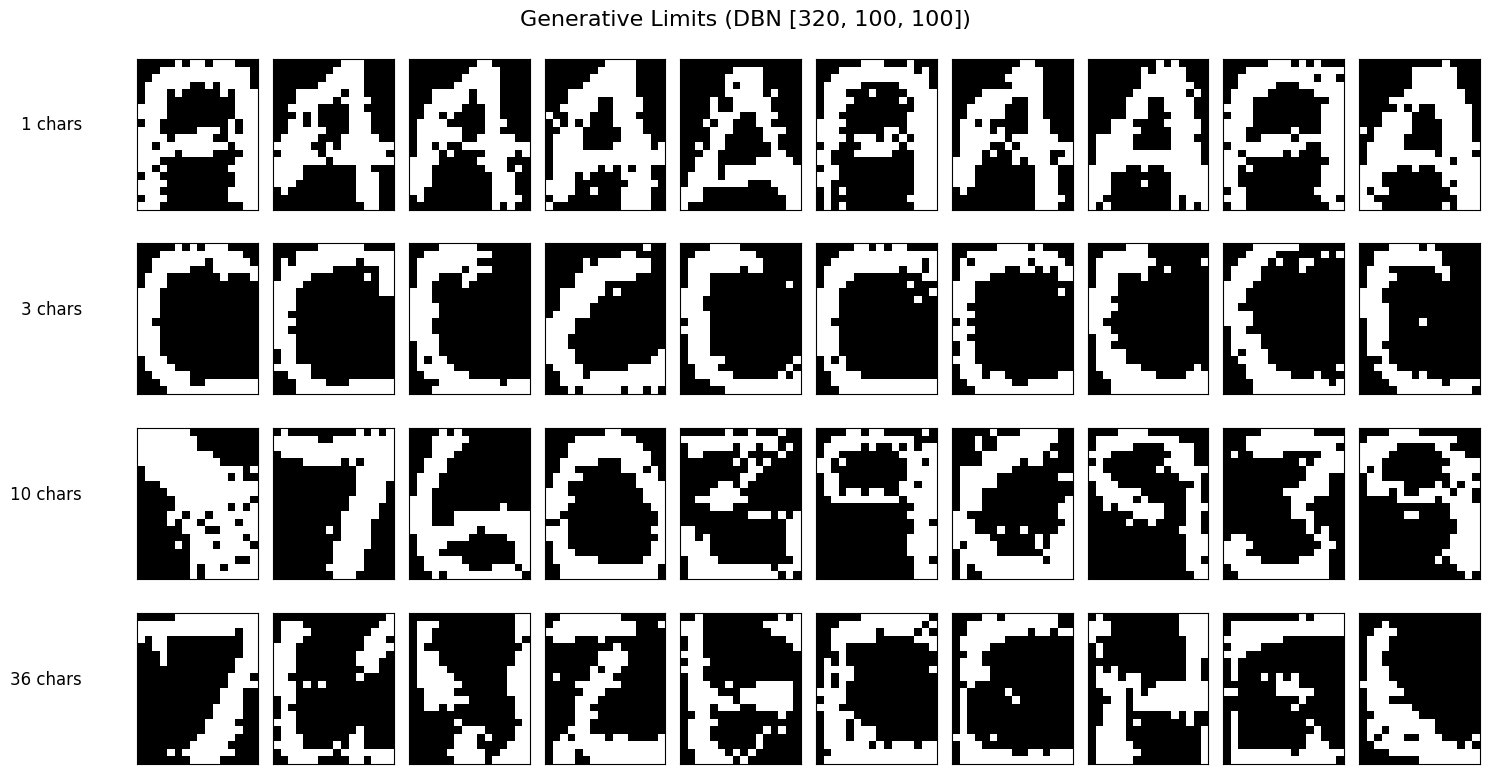

In [8]:
arch = [320, 100, 100]

char_sets = [
    ['A'],                                  # 1 class (very easy)
    ['A', 'B', 'C'],                        # 3 classes (medium)
    [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],         # 10 classes (hard)
    list(range(36))                         # 36 classes (extreme limit)
]

results = []
titles = []

for chars in char_sets:
    print(f"Training on {len(chars)} characters...")
    data = RBM.lire_alpha_digit(PATH_MAT, chars)
    
    dbn = DBN(arch)
    dbn.train_DBN(data, EPOCHS, LEARNING_RATE, BATCH_SIZE, verbose=True) # Unsupervised DBN pre-training
    images = dbn.generer_image_DBN(NB_IMAGES_GEN, ITER_GIBBS, display=False)
    
    results.append(images)
    titles.append(f"{len(chars)} chars")
    
plot_comparison(results, titles, f"Generative Limits (DBN {arch})")

> This is a textbook demonstration of capacity limitations and mode blending in generative models.

**Observation:** With a fixed, relatively small architecture [320, 100, 100], the network easily maps the distribution of 1 or 3 characters, generating perfect samples. However, when forced to learn 10 or 36 characters, the generations degrade into unrecognizable shapes.

**Conclusion:** The network's fixed parameter space becomes overwhelmed by the complexity of 36 distinct modes. Because it cannot effectively partition its latent space for that many classes, it begins sampling interpolations that blend multiple characters together (e.g., a mix of '8', 'B', and 'S'). To successfully generate all 36 characters, the network's capacity (number of neurons) must be vastly increased.